# Length Convergence

In typical RNEMD studies, they regression $\kappa$ versus $1/L$ in order to determine the "infinite-length limit $\kappa$". We do the same here.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from ase.io import read

GPUMD_ROOT = Path("/gpfs/home/djr2473/PSED/gpumd")

# CONFIGS = [
#     "long_300K",
#     "longish_300K",
#     "xlong_300K",
#     "xxlong_300K"
# ]

CONFIGS = [
    "long_675K",
    "longish_675K",
    "xlong_675K",
    "xxlong_675K"
]



GB_LABEL = "bulk_si"

# --- get kappa, R_K, and length for each config ---
lengths_nm = []
kappa_means, kappa_stds = [], []
rk_means, rk_stds = [], []

for config in CONFIGS:
    # kappa and R_K from summary.csv
    summary_path = GPUMD_ROOT / "results" / config / "rnemd" / GB_LABEL / "summary.csv"
    df = pd.read_csv(summary_path)
    kappa_means.append(df["kappa_SI"].mean())
    kappa_stds.append(df["kappa_SI"].std(ddof=1))

    # length from structure.traj
    traj_path = GPUMD_ROOT / "results" / config / "gb_generation" / GB_LABEL / "run_0" / "structure.traj"
    atoms = read(str(traj_path))
    cell_z_nm = np.diag(atoms.cell[:])[2] / 10.0  # Å → nm
    lengths_nm.append(cell_z_nm)

lengths_nm = np.array(lengths_nm)
kappa_means = np.array(kappa_means)
kappa_stds = np.array(kappa_stds)

inv_L = 1.0 / lengths_nm
inv_kappa_means = 1.0 / kappa_means
# error propagation: σ(1/κ) = σ(κ) / κ²
inv_kappa_stds = kappa_stds / kappa_means**2

print("Config          L (nm)    1/L (nm⁻¹)    κ mean ± std (W/m·K)    1/κ mean ± std (m·K/W)")
for c, L, iL, km, ks, ikm, iks in zip(CONFIGS, lengths_nm, inv_L, kappa_means, kappa_stds, inv_kappa_means, inv_kappa_stds):
    print(f"  {c:<14}  {L:7.2f}    {iL:.5f}       {km:6.3f} ± {ks:.3f}       {ikm:.4e} ± {iks:.4e}")

Config          L (nm)    1/L (nm⁻¹)    κ mean ± std (W/m·K)    1/κ mean ± std (m·K/W)
  long_675K        200.85    0.00498       14.361 ± 0.333       6.9634e-02 ± 1.6163e-03
  longish_675K     301.35    0.00332       16.996 ± 2.071       5.8839e-02 ± 7.1696e-03
  xlong_675K       401.27    0.00249       21.535 ± 1.475       4.6436e-02 ± 3.1799e-03
  xxlong_675K      602.17    0.00166       34.389 ± 3.667       2.9079e-02 ± 3.1007e-03


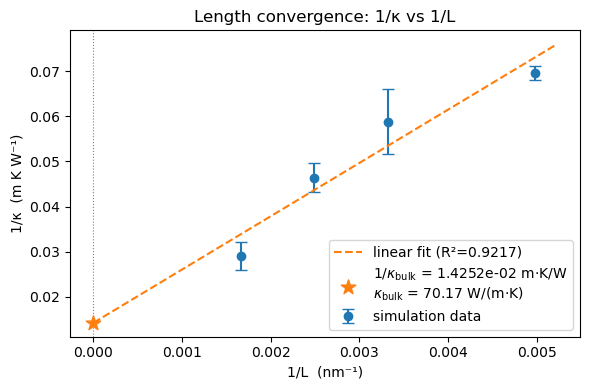


Linear fit:  1/κ = 1.4252e-02 + 1.1806e+01 / L
1/κ_bulk (intercept) = 1.4252e-02 m·K/W
κ_bulk               = 70.167 W/(m·K)  (R² = 0.9217)


In [5]:
# --- linear fit: 1/κ = (1/κ_bulk) + m * (1/L) ---
slope, intercept, r_value, p_value, std_err = stats.linregress(inv_L, inv_kappa_means)
inv_kappa_bulk = intercept
kappa_bulk = 1.0 / inv_kappa_bulk

inv_L_fit = np.linspace(0, inv_L.max() * 1.05, 300)
inv_kappa_fit = slope * inv_L_fit + intercept

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(inv_L, inv_kappa_means, yerr=inv_kappa_stds,
            fmt="o", color="C0", capsize=4, label="simulation data")
ax.plot(inv_L_fit, inv_kappa_fit, "C1--", label=f"linear fit (R²={r_value**2:.4f})")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.scatter([0], [inv_kappa_bulk], marker="*", s=120, color="C1", zorder=5,
           label=f"$1/\\kappa_{{\\mathrm{{bulk}}}}$ = {inv_kappa_bulk:.4e} m·K/W\n"
                 f"$\\kappa_{{\\mathrm{{bulk}}}}$ = {kappa_bulk:.2f} W/(m·K)")

ax.set_xlabel("1/L  (nm⁻¹)")
ax.set_ylabel("1/κ  (m K W⁻¹)")
ax.set_title("Length convergence: 1/κ vs 1/L")
ax.legend()
fig.tight_layout()
plt.savefig(GPUMD_ROOT / "results" / "length_convergence.png", dpi=150)
plt.show()

print(f"\nLinear fit:  1/κ = {inv_kappa_bulk:.4e} + {slope:.4e} / L")
print(f"1/κ_bulk (intercept) = {inv_kappa_bulk:.4e} m·K/W")
print(f"κ_bulk               = {kappa_bulk:.3f} W/(m·K)  (R² = {r_value**2:.4f})")